In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("online_shoppers_intention.csv")

# Basic info
print(df.head())
print(df.info())
print(df.describe())


   Administrative  Administrative_Duration  Informational  \
0               0                      0.0              0   
1               0                      0.0              0   
2               0                      0.0              0   
3               0                      0.0              0   
4               0                      0.0              0   

   Informational_Duration  ProductRelated  ProductRelated_Duration  \
0                     0.0               1                 0.000000   
1                     0.0               2                64.000000   
2                     0.0               1                 0.000000   
3                     0.0               2                 2.666667   
4                     0.0              10               627.500000   

   BounceRates  ExitRates  PageValues  SpecialDay Month  OperatingSystems  \
0         0.20       0.20         0.0         0.0   Feb                 1   
1         0.00       0.10         0.0         0.0   Feb   

In [ ]:
df.isnull().sum()
df.drop_duplicates(inplace=True)


Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [4]:
df['Weekend'] = df['Weekend'].astype(int)
df['Revenue'] = df['Revenue'].astype(int)


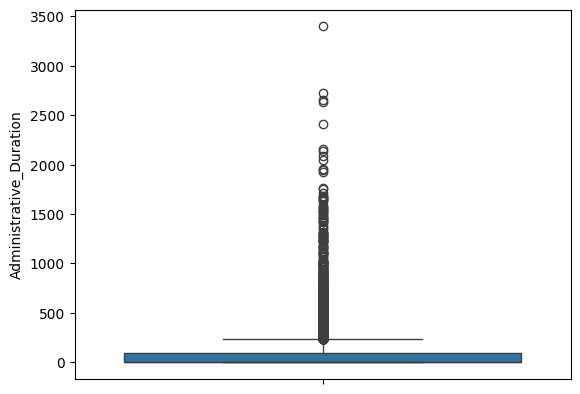

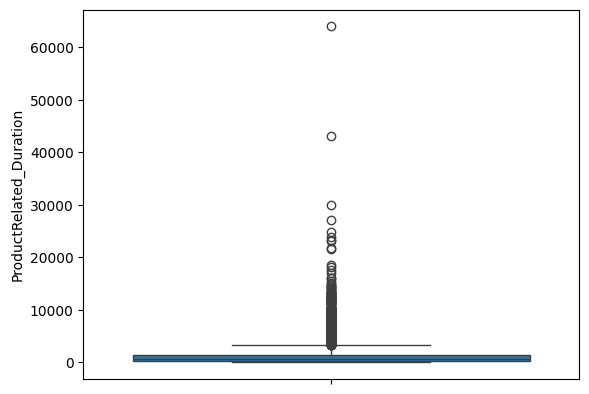

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(df['Administrative_Duration'])
plt.show()

sns.boxplot(df['ProductRelated_Duration'])
plt.show()


In [6]:
df_encoded = pd.get_dummies(df, 
                            columns=['Month', 'VisitorType'], 
                            drop_first=True)


In [7]:
num_cols = [
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay'
]



#use standard scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_encoded[num_cols] = scaler.fit_transform(df_encoded[num_cols])



In [8]:
#Split Data into Train & Test Sets

from sklearn.model_selection import train_test_split

X = df_encoded.drop('Revenue', axis=1)
y = df_encoded['Revenue']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


In [9]:
df_encoded['EngagementScore'] = (
    df['Administrative'] + 
    df['Informational'] + 
    df['ProductRelated']
)

df_encoded['DurationScore'] = (
    df['Administrative_Duration'] + 
    df['Informational_Duration'] + 
    df['ProductRelated_Duration']
)

df_encoded['ExitMinusBounce'] = df['ExitRates'] - df['BounceRates']


In [10]:
df_encoded[['EngagementScore','DurationScore','ExitMinusBounce']] = scaler.fit_transform(
    df_encoded[['EngagementScore','DurationScore','ExitMinusBounce']]
)


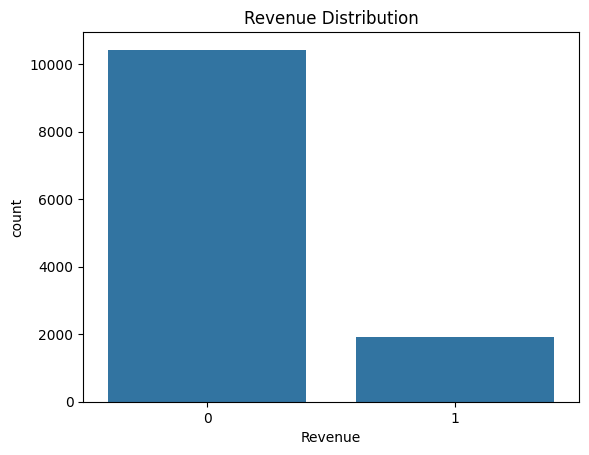

In [11]:
#Revenue distribution

sns.countplot(x='Revenue', data=df)
plt.title("Revenue Distribution")
plt.show()


In [13]:
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4,
    'May': 5, 'June': 6, 'Jul': 7, 'Aug': 8,
    'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

df['MonthNumber'] = df['Month'].map(month_map)


In [14]:
df[['Month', 'MonthNumber']].head()


,Month,MonthNumber
0,Feb,2
1,Feb,2
2,Feb,2
3,Feb,2
4,Feb,2


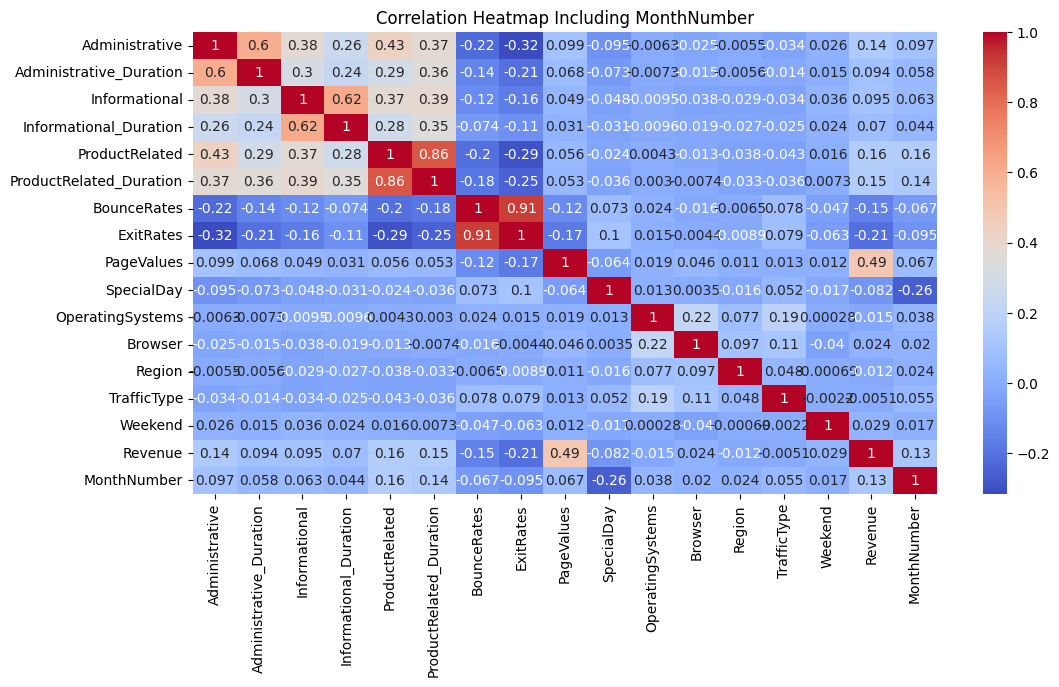

In [ ]:
#Correlation Heatmap 
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(12,6))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=True)
plt.title("Correlation Heatmap Including MonthNumber")
plt.show()



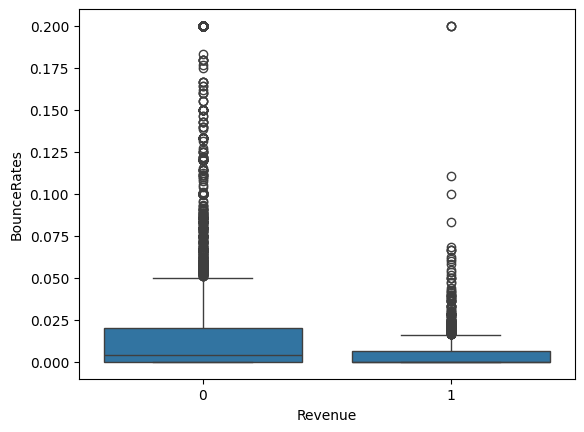

In [17]:
#Boxplot BounceRates vs Revenue

sns.boxplot(x='Revenue', y='BounceRates', data=df)
plt.show()


In [18]:
#Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_pred_lr_proba = log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_lr_proba))
print(classification_report(y_test, y_pred_lr))



Logistic Regression Accuracy: 0.8783652286733701
ROC-AUC: 0.8868785305962212
              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2606
           1       0.72      0.35      0.47       477

    accuracy                           0.88      3083
   macro avg       0.81      0.66      0.70      3083
weighted avg       0.86      0.88      0.86      3083



In [19]:
#Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


Decision Tree Accuracy: 0.8962049951346092
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      2606
           1       0.72      0.54      0.62       477

    accuracy                           0.90      3083
   macro avg       0.82      0.75      0.78      3083
weighted avg       0.89      0.90      0.89      3083



In [20]:
#KNN
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.8712293220888745
              precision    recall  f1-score   support

           0       0.89      0.96      0.93      2606
           1       0.65      0.36      0.47       477

    accuracy                           0.87      3083
   macro avg       0.77      0.66      0.70      3083
weighted avg       0.85      0.87      0.86      3083



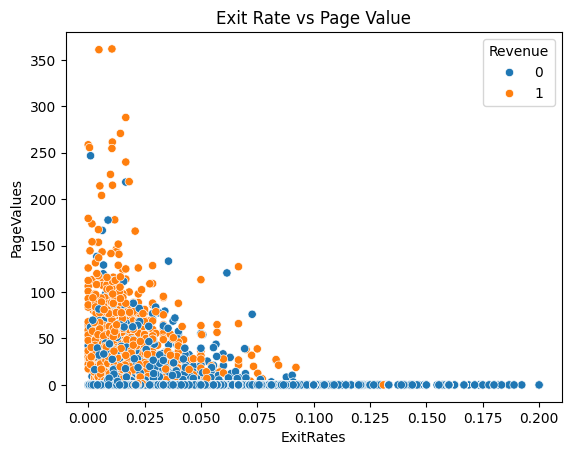

In [21]:
sns.scatterplot(x='ExitRates', y='PageValues', hue='Revenue', data=df)
plt.title("Exit Rate vs Page Value")
plt.show()


In [22]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

# Create SVM model with RBF kernel
svm_clf = SVC(kernel='rbf', probability=True, random_state=42)
svm_clf.fit(X_train, y_train)

# Predictions
y_pred_svm = svm_clf.predict(X_test)
y_pred_svm_proba = svm_clf.predict_proba(X_test)[:, 1]

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_svm_proba))
print(classification_report(y_test, y_pred_svm))


SVM Accuracy: 0.8809601037950049
ROC-AUC: 0.868774043450769
              precision    recall  f1-score   support

           0       0.90      0.97      0.93      2606
           1       0.71      0.39      0.50       477

    accuracy                           0.88      3083
   macro avg       0.80      0.68      0.72      3083
weighted avg       0.87      0.88      0.87      3083



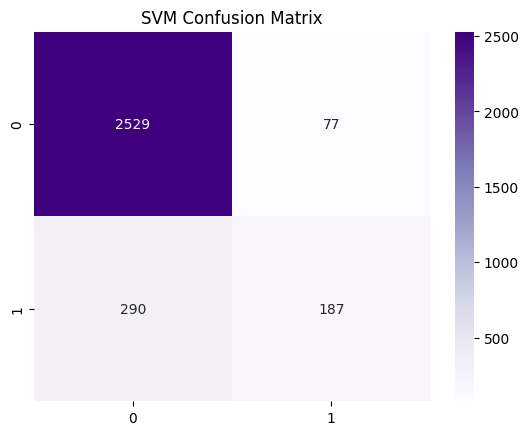

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("SVM Confusion Matrix")
plt.show()
